In [2]:
import numpy as np
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import LogLocator, ScalarFormatter

In [5]:
def extractDistribution(radiusData,weights,fFaz,binVolume,n,pltLabel = '_nolegend_',lineStyle = '-',markerStyle = None):


    weights = weights**1#**0.5
    vTotal = np.sum(weights)
    
    rMax = np.max(radiusData)+1e-32

    rMin = np.min(radiusData)-1e-32
    drV   = (rMax-rMin)/(n-1)
    Edges = np.zeros(shape=(n,1), dtype = float)
    fr = np.zeros(shape=(n-1,1), dtype = float)
    Edges[0]=rMin
    
    tempArray = (radiusData * fFaz)
    for ii in range(n-1):        
        #drV = drV[ii+1] - drV[ii]#binVolume[ii]
        #print(binVolume[int(ii)+1])
        rUpper = binVolume[ii+1]#rMin+(ii+1)*drV;
        rLower = binVolume[ii]#rMin+(ii)*drV;
        Edges[ii+1]= rUpper
        
        if(ii==n-2):
            rUpper=np.inf

        temp = ((tempArray >= rLower) & (tempArray < rUpper))
        #print(temp)        
        fr[ii] = np.sum(weights[temp])    
    
    rV = Edges[:n-1]+np.diff(Edges,axis=0)/2
    minrV = min(rV)

    rV = np.insert(rV, 0 ,0.0)
    fr = np.insert(fr, 0 ,0.0)
    xx = rV
    yy = fr/(vTotal)

    if(minrV>10):
        xx[0] = (minrV)/2

    return xx,yy

In [10]:
def formatFig(xlabel, ylabel, leg, xlim, ylim, loc=1, bbox_to_anchor=None, ncol=1):
    label_font = {'fontname': 'Arial', 'size': 14, 'color': 'black', 'weight': 'bold',
                    'labelpad': 10}
    
    legend = plt.legend(leg, frameon=False,loc=loc, bbox_to_anchor=bbox_to_anchor, ncol=ncol)
    # legend = plt.legend(leg,loc=loc, bbox_to_anchor=bbox_to_anchor, facecolor='white', framealpha=1.0)

    ax = plt.gca()
    ax.tick_params(direction='in', axis='both', which='major', pad=10)
    
    # Set the rotation and label coordinates for the fraction part
    #ax.yaxis.label.set_rotation(0)
    #ax.yaxis.set_label_coords(-0.19, 0.5)

    # Increase font size and make it bold        
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() 
                    + ax.get_yticklabels() + legend.get_texts()):
        item.set_fontsize(14)
        item.set_fontname('Arial')
        item.set_fontweight('bold')
        
    # Remove right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    ax.set_xlabel(xlabel, **label_font)
    ax.set_ylabel(ylabel, **label_font, rotation=90)
    
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)

    plt.tight_layout()

In [144]:
MEMORY_DIR = "./ostrip_initial_0_PcD_equal_PistonPcRec_latest"
#MEMORY_DIR = "./ostrip_initial_0_PcD_equal_PistonPcRec_test_2"
#MEMORY_DIR = "./ostrip_initial_0_clusterPc_equal_PistonPcRec_and_PcI_alpha_070_latest"
clustVol = np.loadtxt(os.path.join(MEMORY_DIR,'clustVolOstRipening_bent.dat'),delimiter=',')
timeArray = np.genfromtxt(os.path.join(MEMORY_DIR,'timeArrayOstRipening_bent.dat'), delimiter=',')
clustID = np.loadtxt(os.path.join(MEMORY_DIR,'clustIDOstRipening_bent.dat'),delimiter=',',dtype=int)
clustPc = np.loadtxt(os.path.join(MEMORY_DIR,'clustPcOstRipening_bent.dat'),delimiter=',')
clustMoles = np.loadtxt(os.path.join(MEMORY_DIR,'clustMolesOstRipening_bent.dat'),delimiter=',')


In [226]:
clustVol[clustVol>0].min()*1e18, clustVol.max()*1e18
print(clustVol[clustVol<0].size)

783


In [22]:
print(clustVol.shape, timeArray.shape, (clustVol<0.0).sum(), timeArray)
ids = np.where(clustVol<0.0)[0]
print(ids)

(6261, 2300) (6261,) 0 [0.00000e+00 0.00000e+00 2.07840e+01 ... 2.59137e+06 2.59197e+06
 2.59257e+06]
[]


In [243]:
print(np.where(clustVol[2]<0), np.where(clustID[2]==1922), clustID[2,6918], clustVol[2,1922])
np.where(clustID[1]!=clustID[2]), clustVol[1,1922], clustVol[2,1922]

(array([], dtype=int64),) (array([6918]),) 1922 8.635e-15


((array([ 8237,  8243,  8268,  8283,  8317,  8402,  8444,  8452,  8458,
          9198, 10327, 18853, 23712, 23892, 23943, 24419, 26637]),),
 8.635e-15,
 8.635e-15)

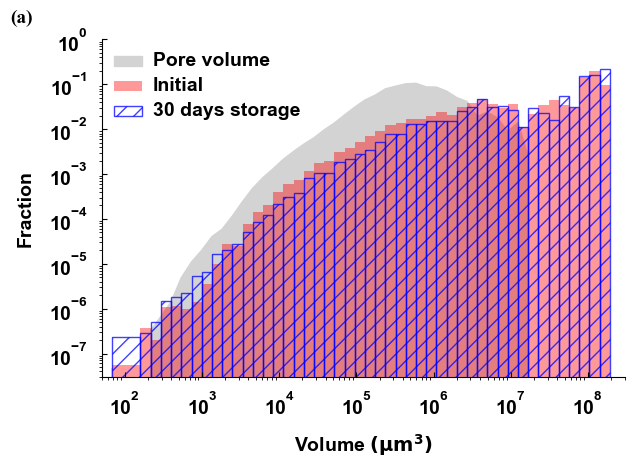

In [11]:
# Set the font family for all elements in the plot
#mpl.rcParams['font.family'] = 'times new roman'
nbinbin = 50
dV = np.logspace(start=np.log10(10e1), stop=np.log10(3e8), num=nbinbin)

elemVol = np.loadtxt('volarray_bent.dat',delimiter=',')
x,y = extractDistribution(elemVol*1e18,(elemVol)*1e18,np.ones_like(elemVol),dV,len(dV)-1)
plt.fill_between(x, y, color='lightgrey', alpha=1,label='Pore volume')

initialVol = clustVol[0]
x,y = extractDistribution(initialVol*1e18,(initialVol)*1e18,np.ones_like(initialVol),dV,len(dV)-1)
plt.hist(x, bins=x, weights=y, log=True, alpha=0.4,label='Initial',color='r')

t = 30
ind = np.argmin(np.abs(timeArray - 3600*24*t))
#ind = np.argmin(np.abs(timeArray - 3600*t))
vol = clustVol[ind]
x,y = extractDistribution(vol*1e18,(vol)*1e18,np.ones_like(vol),dV,len(dV)-1)
hist = plt.hist(x, bins=x, weights=y, log=True, alpha=0, edgecolor='b',facecolor='none',
                label=f'{t} days storage')
                #label=f'{t} hours storage')

for bar in hist[2]:
    bar.set_hatch('//')
    bar.set_alpha(0.75)

plt.gca().set_xscale("log")
plt.gca().set_yscale("log")
#plt.xlim([None,1e9])
plt.ylim([None,1])
#plt.ylim([1e5,10e10])
plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))

# Remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

xlabel = 'Volume $\mathbf{(\mu m^3)}$'
ylabel = 'Fraction'
leg = ['Pore volume', 'Initial', f'{t} days storage']
#leg = ['Pore volume', 'Initial', f'{t} hrs storage']
xlim = [5e1, 3e8]
ylim = [3e-8, 1]

plt.gca().text(-0.175, 1.05, '(a)', transform=plt.gca().transAxes, fontsize=14, fontweight='bold')
formatFig(xlabel, ylabel, leg, xlim, ylim, loc=2, bbox_to_anchor=None)


plt.draw()
plt.savefig(os.path.join(MEMORY_DIR,f"volweighted_distribution_OstRipening_bent_{t}d.png"), dpi=500)
#plt.savefig(os.path.join(MEMORY_DIR,f"volweighted_distribution_OstRipening_bent_{t}h.png"), dpi=500)
#plt.close()


In [52]:
np.array([*zip(x,y)])

array([[3.38942600e+01, 0.00000000e+00],
       [6.77885200e+01, 1.77907604e-07],
       [1.59694189e+02, 3.85000374e-07],
       [2.16508655e+02, 0.00000000e+00],
       [2.93536025e+02, 9.97415146e-07],
       [3.97967455e+02, 1.97028503e-06],
       [5.39552495e+02, 2.70823390e-06],
       [7.31509303e+02, 4.94651427e-06],
       [9.91758660e+02, 5.67936021e-06],
       [1.34459704e+03, 1.44618772e-05],
       [1.82296486e+03, 1.59317494e-05],
       [2.47152180e+03, 2.60720222e-05],
       [3.35081610e+03, 5.98128530e-05],
       [4.54293729e+03, 1.20055231e-04],
       [6.15917991e+03, 1.74655500e-04],
       [8.35043381e+03, 3.54572778e-04],
       [1.13212710e+04, 5.29871741e-04],
       [1.53490441e+04, 5.94780104e-04],
       [2.08097797e+04, 1.08626977e-03],
       [2.82132833e+04, 1.30908618e-03],
       [3.82507344e+04, 1.98093370e-03],
       [5.18592135e+04, 2.89242276e-03],
       [7.03091867e+04, 3.80368938e-03],
       [9.53231142e+04, 4.69422719e-03],
       [1.292362

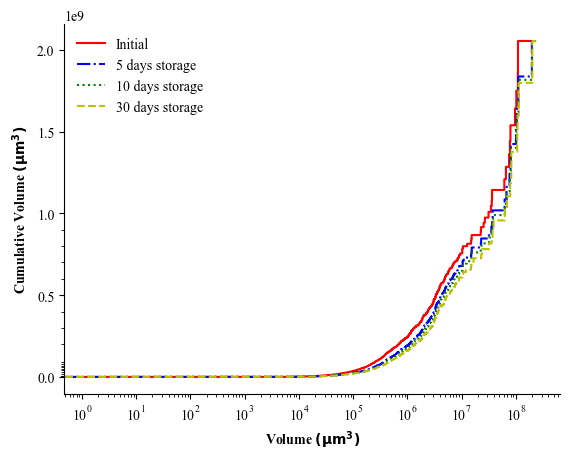

In [ ]:
# Set the font family for all elements in the plot
mpl.rcParams['font.family'] = 'times new roman'

initialVol = clustVol[0]*1e18
initialVol_sort = np.sort(initialVol)
plt.step(initialVol_sort, np.cumsum(initialVol_sort),color='r',label='Initial',linestyle='-',
         marker=None)

t = 5
ind = np.argmin(np.abs(timeArray - 3600*24*t))
vol = clustVol[ind]*1e18
vol_sort = np.sort(vol)
plt.step(vol_sort, np.cumsum(vol_sort),color='b',label=f'{t} days storage',linestyle='-.',
         marker=None)

t = 10
ind = np.argmin(np.abs(timeArray - 3600*24*t))
vol = clustVol[ind]*1e18
vol_sort = np.sort(vol)
plt.step(vol_sort, np.cumsum(vol_sort),color='g',label=f'{t} days storage',linestyle=':',
         marker=None)

t = 30
ind = np.argmin(np.abs(timeArray - 3600*24*t))
vol = clustVol[ind]*1e18
vol_sort = np.sort(vol)
plt.step(vol_sort, np.cumsum(vol_sort),color='y',label=f'{t} days storage',linestyle='--',
         marker=None)


plt.gca().set_xscale("log")
#plt.gca().set_yscale("log")
#plt.xlim([None,1e9])
#plt.ylim([None,1])
#plt.ylim([1e5,10e10])
plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))

# Remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)


plt.legend(loc=2,frameon=False)

plt.xlabel('Volume $\mathbf{(\mu m^3)}$', fontweight="bold")
plt.ylabel('Cumulative Volume $\mathbf{(\mu m^3)}$', fontweight="bold")
#plt.title('$1^{st}$ Drainage', fontweight="bold")

plt.draw()
plt.savefig(os.path.join(MEMORY_DIR,f"cumvol_distribution_OstRipening_bent_{t}d.png"), dpi=500)
#plt.close()

[0.00000e+00 0.00000e+00 0.00000e+00 ... 1.09052e+08 1.09745e+08
 1.94258e+08] [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.75007884e+09
 1.85982384e+09 2.05408184e+09]


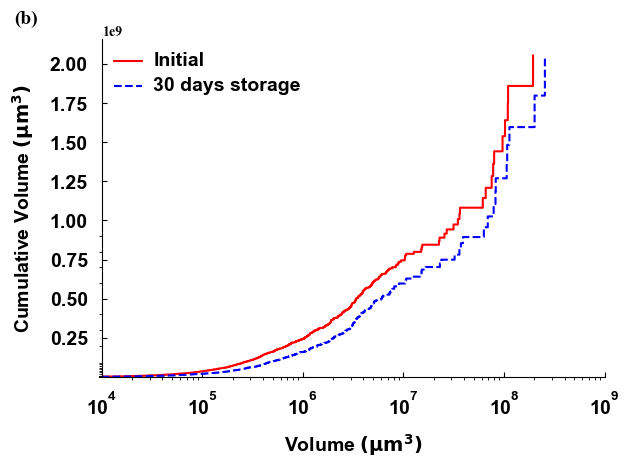

In [12]:
# Set the font family for all elements in the plot
mpl.rcParams['font.family'] = 'times new roman'

initialVol = clustVol[0]*1e18
initialVol_sort = np.sort(initialVol)
plt.step(initialVol_sort, np.cumsum(initialVol_sort),color='r',label='Initial',linestyle='-',
         marker=None, where='post')
print(initialVol_sort, np.cumsum(initialVol_sort))

# t = 5
# ind = np.argmin(np.abs(timeArray - 3600*24*t))
# vol = clustVol[ind]*1e18
# vol_sort = np.sort(vol)
# plt.step(vol_sort, np.cumsum(vol_sort),color='b',label=f'{t} days storage',linestyle='-.',
#          marker=None, where='post')

# t = 10
# ind = np.argmin(np.abs(timeArray - 3600*24*t))
# vol = clustVol[ind]*1e18
# vol_sort = np.sort(vol)
# plt.step(vol_sort, np.cumsum(vol_sort),color='g',label=f'{t} days storage',linestyle=':',
#          marker=None, where='post')


t = 30
ind = np.argmin(np.abs(timeArray - 3600*24*t))
vol = clustVol[ind]*1e18
vol_sort = np.sort(vol)
plt.step(vol_sort, np.cumsum(vol_sort),color='b',label=f'{t} days storage',linestyle='--',
         marker=None, where='post')


plt.gca().set_xscale("log")
#plt.gca().set_yscale("log")
#plt.xlim([1e4,1e9])
#plt.ylim([1e4,None])
#plt.ylim([1e5,10e10])
plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
plt.gca().yaxis.get_offset_text().set_fontweight('bold')

# Remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

xlabel = 'Volume $\mathbf{(\mu m^3)}$'
ylabel = 'Cumulative Volume $\mathbf{(\mu m^3)}$'
#leg = ['Initial', '5 days storage', '10 days storage', '30 days storage']
leg = ['Initial', '30 days storage']
xlim = [1e4,1e9]
ylim = [1e4,None]

plt.gca().text(-0.175, 1.05, '(b)', transform=plt.gca().transAxes, fontsize=14, fontweight='bold')
formatFig(xlabel, ylabel, leg, xlim, ylim, loc=2, bbox_to_anchor=None)



#plt.legend(loc=2,frameon=False)

#plt.xlabel('Volume $\mathbf{(\mu m^3)}$', fontweight="bold")
#plt.ylabel('Cumulative Volume $\mathbf{(\mu m^3)}$', fontweight="bold")
#plt.title('$1^{st}$ Drainage', fontweight="bold")

plt.draw()
plt.savefig(os.path.join(MEMORY_DIR,f"cumvol_distribution_OstRipening_bent_1.png"), dpi=500)
#plt.close()

In [148]:
clustID0 = clustID[0].copy()
elemVol = np.loadtxt('volarray_bent.dat',delimiter=',')
arr = [[0, 0, 0, 0, 0]] # by number
arrVol = [[0, 0, 0, 0, 0]] # by volume
disappearance, fragmentation, normalShrink = 0, 0, 0
coalescence, normalGrowth = 0, 0
disappearance_vol, fragmentation_vol, normalShrink_vol = 0, 0, 0
coalescence_vol, normalGrowth_vol = 0, 0
timeList = [0]
n = clustVol.shape[1]
for i, ids in enumerate(clustID[1:]):
    #i+=1
    cond1a = (clustID0>=0)&(ids<0)
    cond1b = (clustID0<0)&(ids>=0)
    cond1c = np.ones(n, dtype=bool)
    # shrinkage cases
    for id in np.unique(clustID0[cond1a]):
        cond1c[id] = False
        if (clustID0==id).sum()==1:
            disappearance += 1
            disappearance_vol += clustVol[i,id]
            #disappearance_vol += float(elemVol[clustID0==id])
        else:
            newIds = np.unique(ids[clustID0==id])
            newIds = newIds[newIds>=0]
            if newIds.size>1:
                fragmentation += 1
                fragmentation_vol += (clustVol[i,id]-clustVol[i+1,newIds].sum())
                #fragmentation_vol += float(elemVol[(clustID0==id)&(ids<0)])
            else:
                normalShrink += 1
                normalShrink_vol += (float(clustVol[i,id]-clustVol[i+1,newIds]))
                #normalShrink_vol += float(elemVol[(clustID0==id)&(ids<0)])
            cond1c[newIds] = False

    # growth cases
    for id in np.unique(ids[cond1b]):
        oldIds = np.unique(clustID0[ids==id])
        oldIds = oldIds[oldIds>=0]
        cond1c[oldIds] = False
        cond1c[id] = False
        if oldIds.size>1:
            coalescence += 1
            coalescence_vol += (clustVol[i+1,id]-clustVol[i,oldIds].sum())
            #coalescence_vol += float(elemVol[(clustID0<0)&(ids==id)])
        else:
            #print('@@',id,oldIds,clustVol[i+1,id],clustVol[i,oldIds].sum())
            normalGrowth += 1
            normalGrowth_vol += (float(clustVol[i+1,id]-clustVol[i,oldIds]))
            #normalGrowth_vol += float(elemVol[(clustID0<0)&(ids==id)])
        
    # other cases
    deltaVol = clustVol[i+1]-clustVol[i]
    cond1c1 = cond1c&(deltaVol<0.0)
    cond1c2 = cond1c&(deltaVol>0.0)
    normalShrink_vol += np.abs(deltaVol[cond1c1]).sum()
    normalGrowth_vol += deltaVol[cond1c2].sum()

    #break
    clustID0[:] = ids

    arr.append([disappearance, fragmentation, normalShrink, 
                coalescence, normalGrowth])
    arrVol.append([disappearance_vol, fragmentation_vol, normalShrink_vol,
                coalescence_vol, normalGrowth_vol])
arr = np.array(arr)
arrVol = np.array(arrVol)
        

In [149]:
i,(cond1a&cond1b).sum(), (ids==29).sum(), clustID0[[0,25918,6318]],ids[[0,25918,6318]]

(6259, 0, 1, array([-5, 29, -5]), array([-5, 29, -5]))

In [150]:
clustVol[i-1].sum()-clustVol[i].sum(), (disappearance_vol+fragmentation_vol+normalShrink_vol),(coalescence_vol+normalGrowth_vol)

(-8.577428004065204e-16, 1.4996125717236967e-10, 1.4905217731842e-10)

In [151]:
disappearance_vol, fragmentation_vol, normalShrink_vol,coalescence_vol, normalGrowth_vol, normalShrink_vol-normalGrowth_vol

(0.0,
 4.795784440000174e-14,
 1.4991329932796967e-10,
 3.289982169999914e-13,
 1.4872317910142e-10,
 1.1901202265496634e-12)

In [8]:
clustID.shape, clustVol.shape

((6261, 27329), (6261, 2300))

In [116]:
condShrink.sum(), condGrowth.sum(), totalChange.sum()
clustID0[totalChange], ids[totalChange]

(array([  -5, 1902, 1903, 1903, 1902, 1902, 1902, 1902, 1902, 1902, 1903,
        1903, 1903, 1903, 1903]),
 array([1904, 1904, 1904, 1904, 1904, 1904, 1904, 1904, 1904, 1904, 1904,
        1904, 1904, 1904, 1904]))

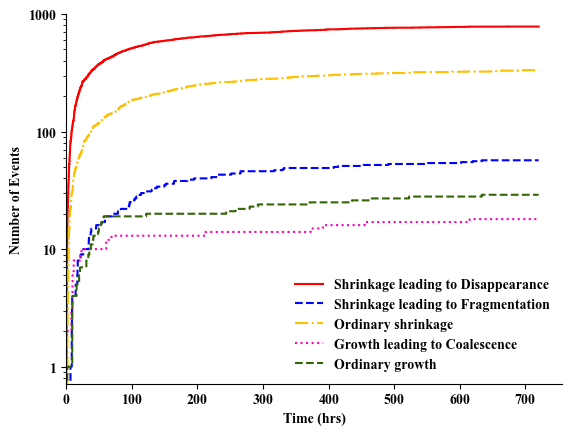

In [ ]:
mpl.rcParams['font.family'] = 'times new roman'
mpl.rcParams['font.weight'] = 'bold'

plt.plot(timeArray/3600,arr[:,0],color='r',label='Shrinkage leading to Disappearance',
         linestyle='-',marker=None)
plt.plot(timeArray/3600,arr[:,1],color='b',label='Shrinkage leading to Fragmentation',
         linestyle='--',marker=None)
plt.plot(timeArray/3600,arr[:,2],color='#FFBF02',label='Ordinary shrinkage',
         linestyle='-.',marker=None)
plt.plot(timeArray/3600,arr[:,3],color='#FF00BF',label='Growth leading to Coalescence',
         linestyle=':',marker=None)
plt.plot(timeArray/3600,arr[:,4],color='#336605',label='Ordinary growth',linestyle='--',marker=None)

plt.gca().set_yscale("log")
#plt.gca().set_yscale("log")
plt.xlim([0,None])
plt.ylim([None, 1000])
#plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
#plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0))
plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
#plt.gca().ticklabel_format(style='plain', axis='y')
#plt.gca().yaxis.set_major_locator(LogLocator(base=10.0))
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
#plt.gca().tick_params(axis='y', which='both', labelsize=10)


# Remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)


plt.legend(loc=4,frameon=False)

plt.xlabel('Time (hrs)', fontweight="bold")
plt.ylabel('Number of Events', fontweight="bold")
#plt.title('$1^{st}$ Drainage', fontweight="bold")

plt.draw()
plt.savefig(os.path.join(MEMORY_DIR,f"Events_Types_OstRipening_bent.png"), dpi=500)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30.]
[  0 252 369 442 506 548 588 612 633 651 667 681 692 697 712 723 731 741
 749 756 761 765 767 770 773 777 781 782 782 783 783]


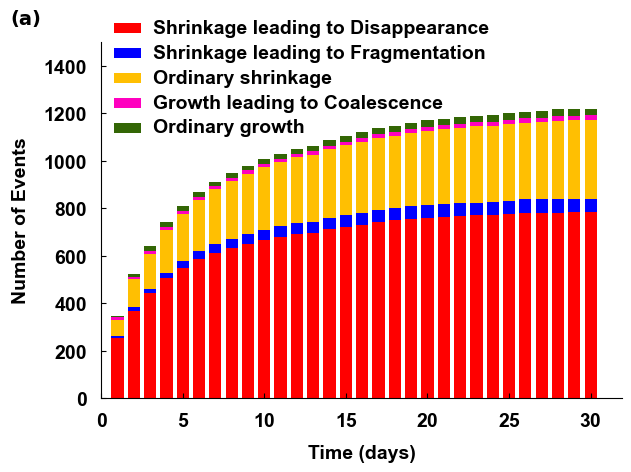

In [39]:
# Filter data for every 12-hour intervals
x = 24  # hours interval
interval = x * 3600  # 12 hours in seconds
time_xh = np.linspace(0,3600*24*30,int((30*24/x)+1))
indices_xh = np.argmin(np.abs(timeArray[:,None] - time_xh),axis=0)
time_xh = time_xh/(3600*24)
arr_xh = arr[indices_xh]

print(time_xh)
print(arr_xh[:,0])
w = 0.75
plt.bar(time_xh, arr_xh[:, 0], label='Shrinkage leading to Disappearance', color='r', width=w)
plt.bar(time_xh, arr_xh[:, 1], bottom=arr_xh[:, 0], label='Shrinkage leading to Fragmentation', color='b', width=w)
plt.bar(time_xh, arr_xh[:, 2], bottom=arr_xh[:, 0] + arr_xh[:, 1], label='Ordinary shrinkage', color='#FFBF02', width=w)
plt.bar(time_xh, arr_xh[:, 3], bottom=arr_xh[:, 0] + arr_xh[:, 1] + arr_xh[:, 2], label='Growth leading to Coalescence', color='#FF00BF', width=w)
plt.bar(time_xh, arr_xh[:, 4], bottom=arr_xh[:, 0] + arr_xh[:, 1] + arr_xh[:, 2] + arr_xh[:, 3], label='Ordinary growth', color='#336605', width=w)

# Set y-axis to log scale
#plt.gca().set_yscale("log")

# Set axis limits
#plt.xlim([0, None])
#plt.ylim([0, 1430])

# Remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add legend
#plt.legend(loc=2, frameon=False)

# Add labels
#plt.xlabel('Time (days)', fontweight="bold")
#plt.ylabel('Number of Events', fontweight="bold")

xlabel = 'Time (days)'
ylabel = 'Number of Events'
xlim = [0, None]
ylim = [0, 1500]
leg = ['Shrinkage leading to Disappearance',
          'Shrinkage leading to Fragmentation',
          'Ordinary shrinkage',
          'Growth leading to Coalescence',
          'Ordinary growth']
formatFig(xlabel, ylabel, leg, xlim, ylim, loc=2, bbox_to_anchor=(0.0, 1.1))
plt.gca().text(-0.175, 1.05, '(a)', transform=plt.gca().transAxes, fontsize=14, fontweight='bold')
# Save the plot
plt.draw()
plt.savefig(os.path.join(MEMORY_DIR, f"24h_Stacked_Events_Types_OstRipening_bent.png"), dpi=500)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30.]
[  0 252 369 442 506 548 588 612 633 651 667 681 692 697 712 723 731 741
 749 756 761 765 767 770 773 777 781 782 782 783 783]


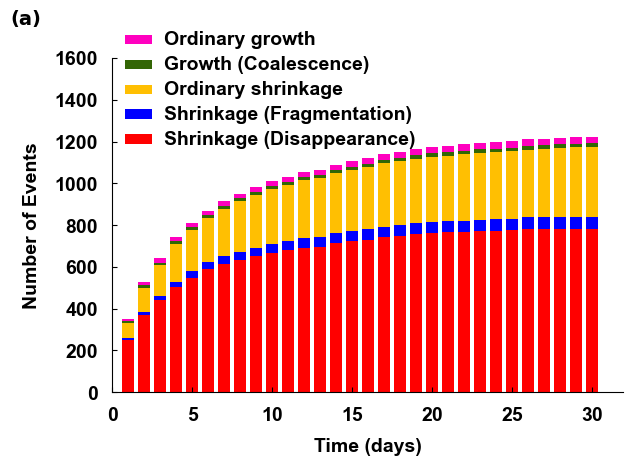

In [197]:
# Filter data for every 12-hour intervals
x = 24  # hours interval
interval = x * 3600  # 12 hours in seconds
time_xh = np.linspace(0,3600*24*30,int((30*24/x)+1))
indices_xh = np.argmin(np.abs(timeArray[:,None] - time_xh),axis=0)
time_xh = time_xh/(3600*24)
arr_xh = arr[indices_xh]

print(time_xh)
print(arr_xh[:,0])
w = 0.75
plt.bar(time_xh, arr_xh[:, 4], bottom=arr_xh[:,0]+arr_xh[:,1]+arr_xh[:,2]+arr_xh[:,3],
        label='Ordinary growth', color='#FF00BF', width=w)
plt.bar(time_xh, arr_xh[:, 3], bottom=arr_xh[:,0]+arr_xh[:,1]+arr_xh[:,2], 
        label='Growth (Coalescence)', color='#336605', width=w)
plt.bar(time_xh, arr_xh[:, 2], bottom=arr_xh[:,0]+arr_xh[:,1], label='Ordinary shrinkage', 
        color='#FFBF02', width=w)
plt.bar(time_xh, arr_xh[:, 1], bottom=arr_xh[:,0], label='Shrinkage (Fragmentation)',
        color='b', width=w)
plt.bar(time_xh, arr_xh[:,0], label='Shrinkage (Disappearance)', color='r', width=w)


# Remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

xlabel = 'Time (days)'
ylabel = 'Number of Events'
xlim = [0, None]
ylim = [0, 1600]
leg = ['Ordinary growth',
       'Growth (Coalescence)',
       'Ordinary shrinkage',
       'Shrinkage (Fragmentation)',
       'Shrinkage (Disappearance)']
#leg = []
plt.gca().text(-0.2, 1.1, '(a)', transform=plt.gca().transAxes, fontsize=14, fontweight='bold')
formatFig(xlabel, ylabel, leg, xlim, ylim, loc=2, bbox_to_anchor=(0.0, 1.12))
#formatFig(xlabel, ylabel, leg, xlim, ylim, loc=2, bbox_to_anchor=(0.0, 1.4))

# Save the plot
plt.draw()
plt.savefig(os.path.join(MEMORY_DIR, f"24h_Stacked_Events_Types_OstRipening_bent.png"), dpi=500)

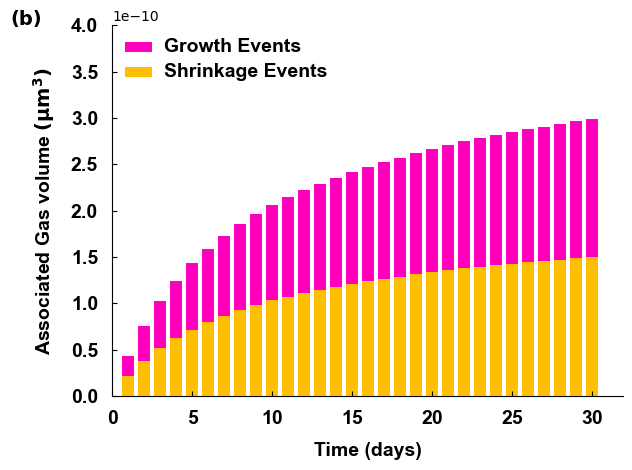

In [200]:
# w=0.1
# time_xh = 3600*24*np.array([1,2,5,10,20,30])
# numG = time_xh.size
# indices_xh = np.argmin(np.abs(timeArray[:,None] - time_xh),axis=0)
# x = np.linspace(0.5,numG+1, numG)
# arrVol_xh = arrVol[indices_xh]
# print(arrVol_xh)

x = 24  # hours interval
interval = x * 3600  # 12 hours in seconds
time_xh = np.linspace(0,3600*24*30,int((30*24/x)+1))
indices_xh = np.argmin(np.abs(timeArray[:,None] - time_xh),axis=0)
time_xh = time_xh/(3600*24)
arrVol_xh = arrVol[indices_xh]
#print(arrVol_xh)

w = 0.75
# plt.bar(time_xh, arrVol_xh[:, 4], 
#         bottom=arrVol_xh[:,0]+arrVol_xh[:,1]+arrVol_xh[:,2]+arrVol_xh[:,3],
#         label='Ordinary growth', color='#FF00BF', width=w)
# plt.bar(time_xh, arrVol_xh[:, 3], bottom=arrVol_xh[:,0]+arrVol_xh[:,1]+arrVol_xh[:,2], 
#         label='Growth leading to Coalescence', color='#336605', width=w)
# plt.bar(time_xh, arrVol_xh[:, 2], bottom=arrVol_xh[:,0]+arrVol_xh[:,1], label='Ordinary shrinkage', 
#         color='#FFBF02', width=w)
# plt.bar(time_xh, arrVol_xh[:, 1], bottom=arrVol_xh[:,0], label='Shrinkage leading to Fragmentation',
#         color='b', width=w)
# plt.bar(time_xh, arrVol_xh[:,0], label='Shrinkage leading to Disappearance', color='r', width=w)


plt.bar(time_xh, arrVol_xh[:, 3]+arrVol_xh[:, 4], 
        bottom=arrVol_xh[:,0]+arrVol_xh[:,1]+arrVol_xh[:,2], 
        label='Growth events', color='#FF00BF', width=w)
plt.bar(time_xh, arrVol_xh[:,0]+arrVol_xh[:, 1]+arrVol_xh[:, 2], 
        label='Shrinkage events', 
        color='#FFBF02', width=w)


# Remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Set y-axis to log scale
#plt.gca().set_yscale("log")

xlabel = 'Time (days)'
ylabel = 'Associated Gas volume $\mathbf{(\mu m^3)}$'
xlim = [0, None]
ylim = [None, 4e-10]
#ylim = [None, None]
leg=['Growth Events', 'Shrinkage Events']
# leg = ['Ordinary growth',
#        'Growth (Coalescence)',
#        'Ordinary shrinkage',
#        'Shrinkage (Fragmentation)',
#        'Shrinkage (Disappearance)']
plt.gca().text(-0.2, 1, '(b)', transform=plt.gca().transAxes, fontsize=14, fontweight='bold')
#formatFig(xlabel, ylabel, leg, xlim, ylim, loc=2, bbox_to_anchor=(0.5, 1.3), ncol=5)
formatFig(xlabel, ylabel, leg, xlim, ylim, loc=2, bbox_to_anchor=(0.0, 1.0))

# Save the plot
plt.draw()
plt.savefig(os.path.join(MEMORY_DIR, f"24h_Stacked_Events_Types_by_vol_OstRipening_bent_1.png"), dpi=500)

In [92]:
f'saturation_by_position_OstRipening_bent_{nBins+1}bins.dat'

'saturation_by_position_OstRipening_bent_1001bins.dat'

[0.     0.0025 0.005  0.0075 0.01   0.0125 0.015  0.0175 0.02   0.0225
 0.025  0.0275 0.03   0.0325 0.035  0.0375 0.04   0.0425 0.045  0.0475
 0.05   0.0525 0.055  0.0575 0.06   0.0625 0.065  0.0675 0.07   0.0725
 0.075  0.0775 0.08   0.0825 0.085  0.0875 0.09   0.0925 0.095  0.0975
 0.1    0.1025 0.105  0.1075 0.11   0.1125 0.115  0.1175 0.12   0.1225
 0.125  0.1275 0.13   0.1325 0.135  0.1375 0.14   0.1425 0.145  0.1475
 0.15   0.1525 0.155  0.1575 0.16   0.1625 0.165  0.1675 0.17   0.1725
 0.175  0.1775 0.18   0.1825 0.185  0.1875 0.19   0.1925 0.195  0.1975
 0.2    0.2025 0.205  0.2075 0.21   0.2125 0.215  0.2175 0.22   0.2225
 0.225  0.2275 0.23   0.2325 0.235  0.2375 0.24   0.2425 0.245  0.2475
 0.25   0.2525 0.255  0.2575 0.26   0.2625 0.265  0.2675 0.27   0.2725
 0.275  0.2775 0.28   0.2825 0.285  0.2875 0.29   0.2925 0.295  0.2975
 0.3    0.3025 0.305  0.3075 0.31   0.3125 0.315  0.3175 0.32   0.3225
 0.325  0.3275 0.33   0.3325 0.335  0.3375 0.34   0.3425 0.345  0.3475
 0.35 

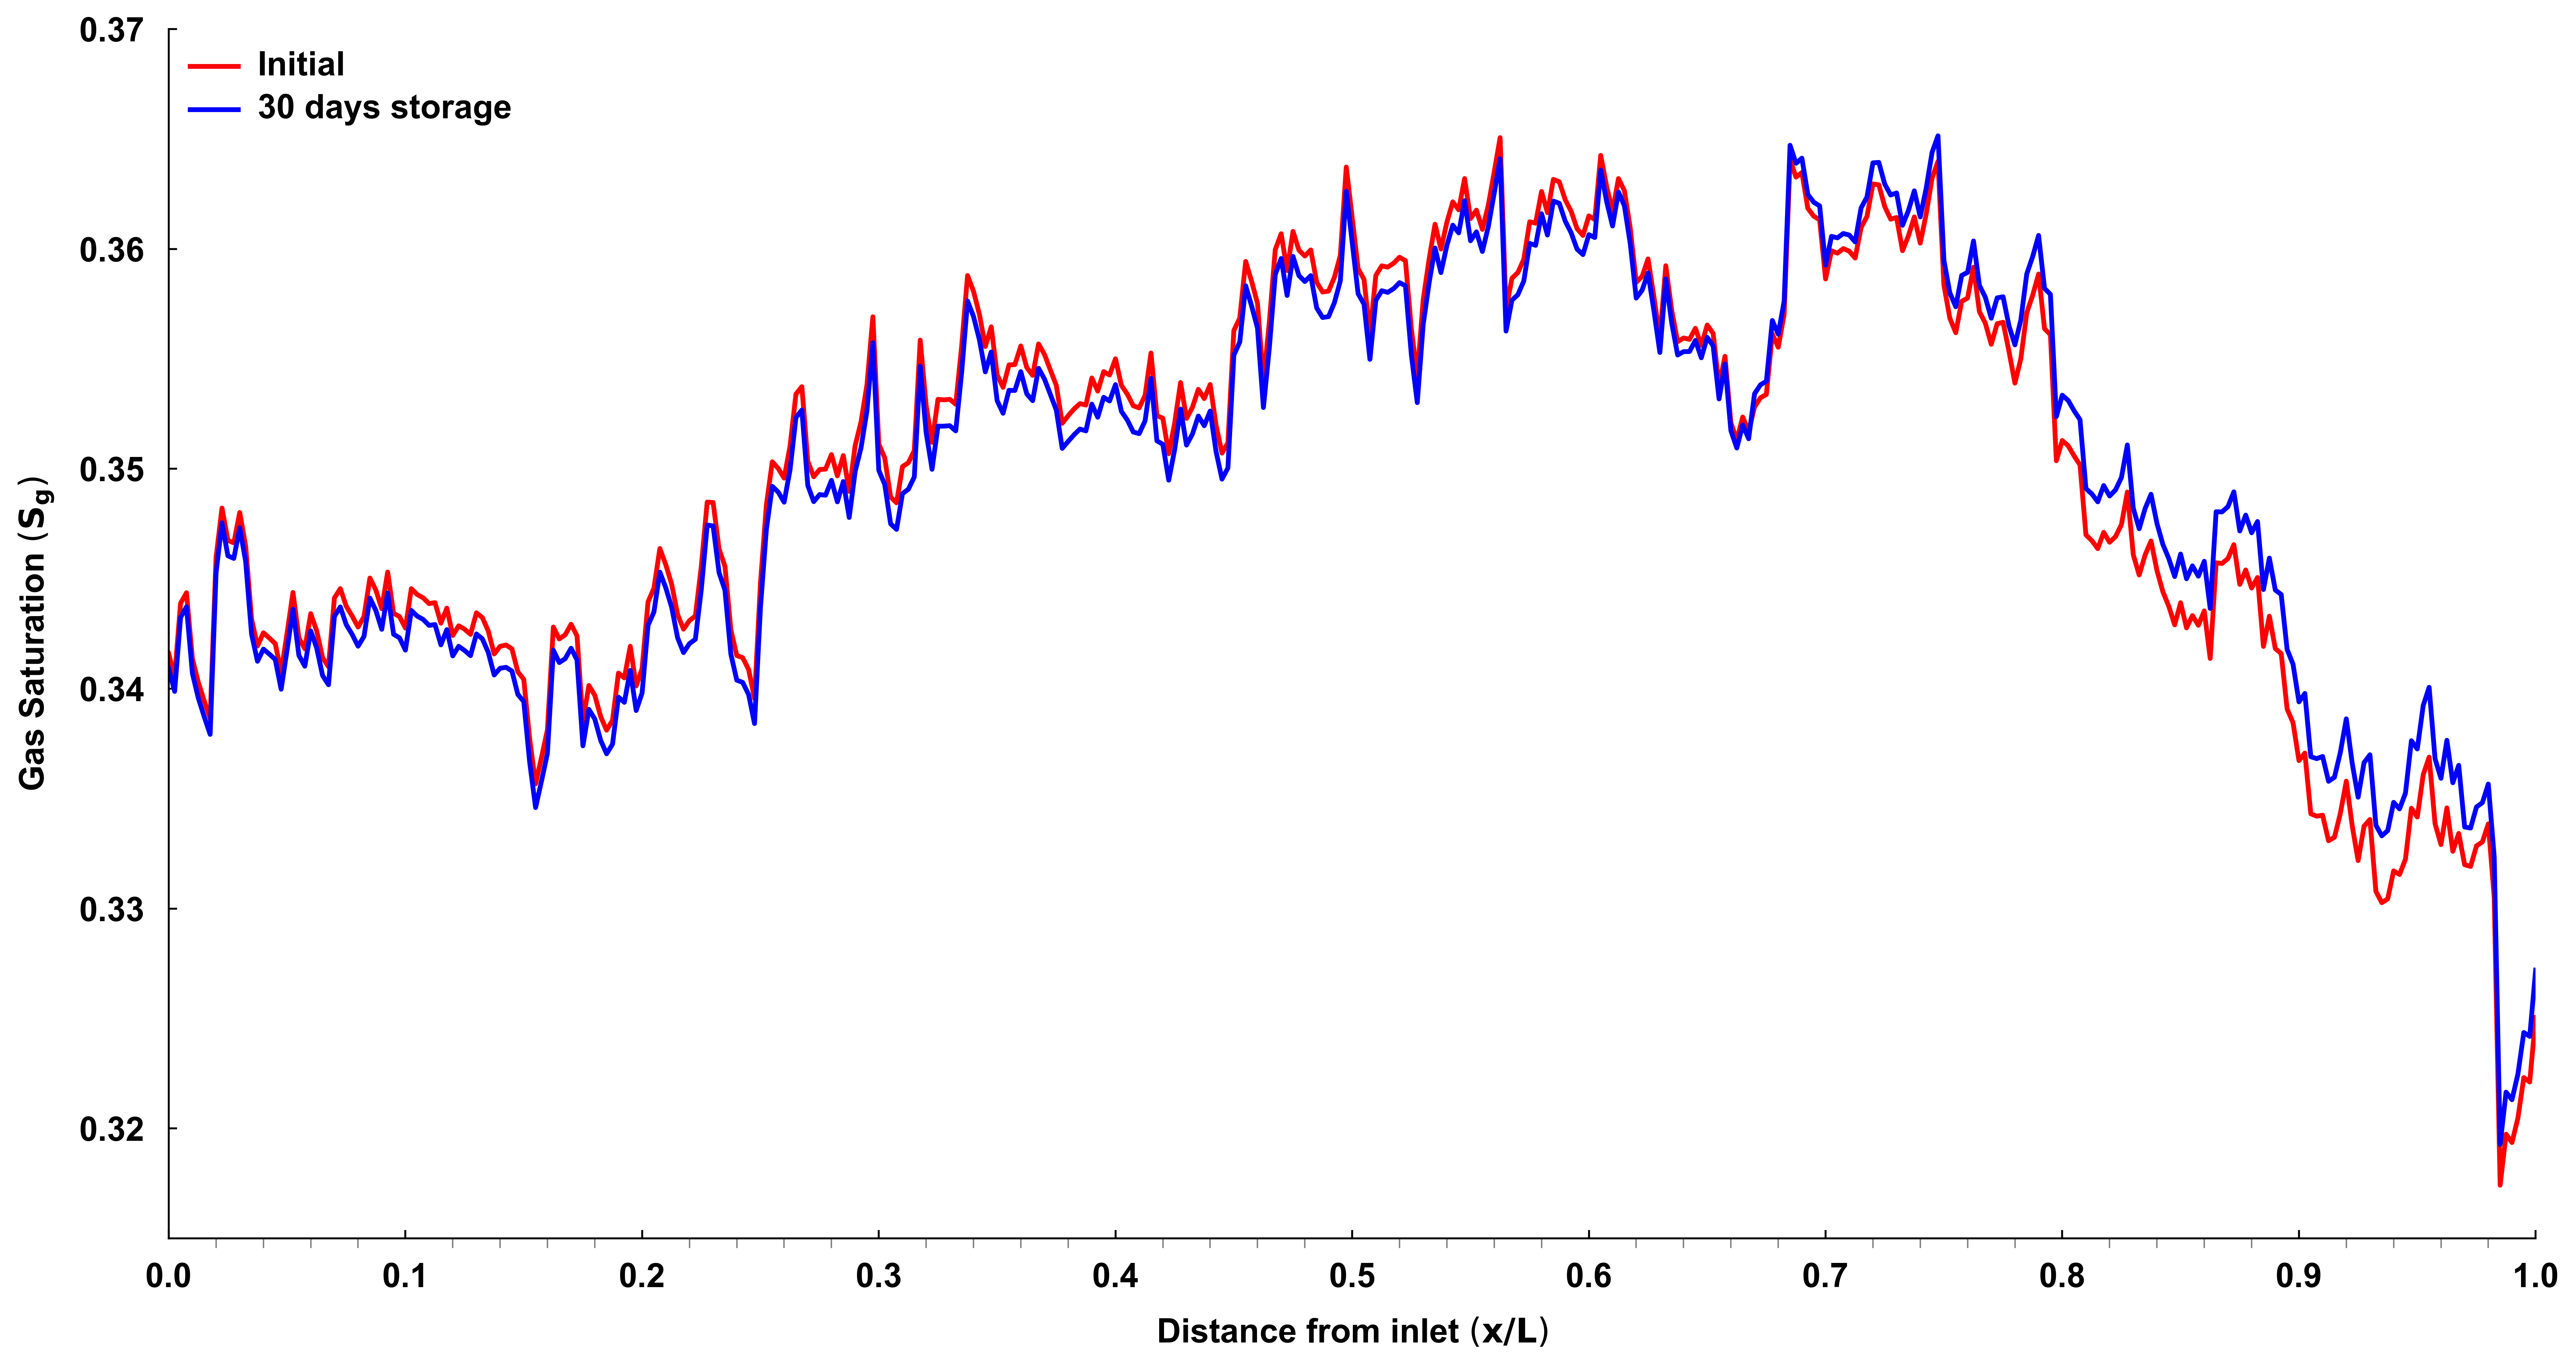

In [9]:
from matplotlib.pyplot import figure
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

figure(figsize=(15, 8), dpi=500)
plt.rcParams['lines.linewidth'] = 5
nBins = 200
satListArray = np.loadtxt(
    os.path.join(MEMORY_DIR,f'saturation_by_position_OstRipening_bent_{nBins}bins_5.dat'),delimiter=',')
#timeList = np.array([12,24,48,120,240,360,480,600,720])
#timeList = np.array([12,24,240,720])
timeList = np.array([0,720])
xarray = np.linspace(0, 1, 2*nBins+1)
print(xarray)
colorlist=['r','b']
for i, t in enumerate(timeList):
    #satlist = np.insert(satListArray[i], 0, 0.0)
    satlist = satListArray[i]
    plt.plot(xarray, 1-satlist, linestyle='-', color=colorlist[i], marker=None, linewidth=2)

plt.gca().xaxis.set_minor_locator(AutoMinorLocator(5)) 
plt.gca().xaxis.set_major_locator(MultipleLocator(0.1))
#plt.gca().xaxis.set_minor_locator(MultipleLocator(0.05))
plt.gca().tick_params(axis='x', which='minor', length=4, color='gray')

xlabel = 'Distance from inlet $(\mathbf{x/L})$'
ylabel = 'Gas Saturation $(\mathbf{S_g})$'
xlim = [0.0, 1.0]
ylim = [0.315, 0.37]
# leg = ['12 hrs storage',
#           '24 hrs storage',
#           '10 days storage',
#           '30 days storage']
leg = ['Initial', '30 days storage']
formatFig(xlabel, ylabel, leg, xlim, ylim, loc=2, bbox_to_anchor=None)


plt.draw()
plt.savefig(os.path.join(MEMORY_DIR, f"saturation_profile_by_position_OstRipening_bent_5_200bin_gas_1.png"), dpi=500)
    

In [81]:
satListArray

array([[0.605824, 0.684508, 0.78682 , ..., 0.947983, 0.414623, 0.672276],
       [0.605575, 0.68544 , 0.791321, ..., 0.947924, 0.413944, 0.670669],
       [0.604797, 0.686617, 0.796356, ..., 0.947856, 0.412841, 0.668856],
       ...,
       [0.594039, 0.695096, 0.800794, ..., 0.960686, 0.406477, 0.659002],
       [0.592965, 0.695211, 0.800023, ..., 0.960524, 0.405777, 0.657997],
       [0.591998, 0.695113, 0.799446, ..., 0.960349, 0.405177, 0.657122]])

In [178]:
time_12h = np.linspace(0,3600*24*30,61)
indices_12h = np.argmin(np.abs(timeArray[:,None] - time_12h),axis=0)

print(indices_12h, time_12h, timeArray[indices_12h])

[   0  419  739  971 1164 1345 1490 1646 1787 1912 2030 2157 2267 2372
 2482 2582 2684 2786 2874 2968 3059 3149 3236 3329 3412 3494 3575 3662
 3755 3841 3925 4009 4092 4177 4261 4340 4422 4507 4588 4665 4744 4821
 4897 4970 5050 5127 5203 5278 5351 5430 5505 5584 5660 5736 5810 5888
 5963 6036 6112 6185 6259] [      0.   43200.   86400.  129600.  172800.  216000.  259200.  302400.
  345600.  388800.  432000.  475200.  518400.  561600.  604800.  648000.
  691200.  734400.  777600.  820800.  864000.  907200.  950400.  993600.
 1036800. 1080000. 1123200. 1166400. 1209600. 1252800. 1296000. 1339200.
 1382400. 1425600. 1468800. 1512000. 1555200. 1598400. 1641600. 1684800.
 1728000. 1771200. 1814400. 1857600. 1900800. 1944000. 1987200. 2030400.
 2073600. 2116800. 2160000. 2203200. 2246400. 2289600. 2332800. 2376000.
 2419200. 2462400. 2505600. 2548800. 2592000.] [      0.    43069.2   86394.9  129554.   172806.   216073.   259199.
  302623.   345384.   389094.   432246.   475444.   518426.  

In [ ]:
clustPc

array([[ 1365.67, 43847.6 , 38744.5 , ...,     0.  ,     0.  ,     0.  ],
       [ 1365.67, 43847.6 , 38744.5 , ...,     0.  ,     0.  ,     0.  ],
       [ 1365.67, 43846.3 , 38743.5 , ...,     0.  ,     0.  ,     0.  ],
       ...,
       [ 1365.67,  7736.02,  4815.31, ...,     0.  ,     0.  ,     0.  ],
       [ 1365.67,  7732.55,  4813.51, ...,     0.  ,     0.  ,     0.  ],
       [ 1365.67,  7729.08,  4811.71, ...,     0.  ,     0.  ,     0.  ]])

: 